# AIE332 Assignment 2: LSTM, GRU & Attention

## Dataset Description

For this assignment, I used the UCI Human Activity Recognition (HAR) dataset.

The dataset contains sensor data collected from smartphones while people performed different activities. Each sample contains 128 time steps with 9 features at each time step. The dataset is divided into training and testing sets, with 7,352 training samples and 2,947 testing samples.

The goal is to classify each sequence into one of 6 human activities.

This dataset is suitable for sequence modeling because the data is collected over time, and the order of the time steps contains important information. LSTM and GRU models can learn patterns and dependencies from these sequences.

## 1. Import Required Libraries

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Imports successful!")

Imports successful!


## 2. Load and Prepare the Dataset

In [34]:
import os

downloads_path = r"C:\Users\hp\Downloads"

files = os.listdir(downloads_path)

for file in files:
    if file.endswith(".zip"):
        print(file)

577534f7-3377-4219-98ec-0b7ce82b8292_Export-649b7591-54ef-4d96-881d-90e53ec35473.zip
849554870-مشروع-إبراهيم-الرفاعى-Repaired.zip
8857315f-5bbc-41e6-b4d9-acbe33aa0eb5_ExportBlock-ecf6a2a5-944b-464a-a98c-26ee71171e40.zip
advantages-concept-illustration.zip
ai-engineer-roadmap-2024.zip
archive.zip
assignment 1-3.pdf.zip
Assignment 4.pdf.zip
Blue Yellow Simple Illustrative We Are Hiring Instagram Post (1).zip
Blue Yellow Simple Illustrative We Are Hiring Instagram Post (2).zip
Blue Yellow Simple Illustrative We Are Hiring Instagram Post (3).zip
Blue Yellow Simple Illustrative We Are Hiring Instagram Post (4).zip
Blue Yellow Simple Illustrative We Are Hiring Instagram Post.zip
Bootslander.zip
Cairo.zip
city-bus-concept-illustration.zip
CN.zip
Competitor_Analysis_GoogleSheet.zip
compressed (1).zip
compressed.zip
Computer Architecture.zip
D&AA.zip
demo project.zip
Discrete Math.zip
Files.zip
Going Where Survey.csv.zip
hand-drawn-microlearning-illustration.zip
HP-PARK-v1.9.1.zip
human+activit

In [35]:
import zipfile
import os

zip_path = r"C:\Users\hp\Downloads\human+activity+recognition+using+smartphones.zip"
extract_path = r"C:\Users\hp\data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")
print(os.listdir(extract_path))

Extraction completed!
['UCI HAR Dataset', 'UCI HAR Dataset.names', 'UCI HAR Dataset.zip', '__MACOSX']


In [36]:
inner_zip_path = r"C:\Users\hp\data\UCI HAR Dataset.zip"

with zipfile.ZipFile(inner_zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Inner extraction completed!")
print(os.listdir(extract_path))

Inner extraction completed!
['UCI HAR Dataset', 'UCI HAR Dataset.names', 'UCI HAR Dataset.zip', '__MACOSX']


In [37]:
data_path = r"C:\Users\hp\data\UCI HAR Dataset"

print(os.listdir(data_path))

['.DS_Store', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'README.txt', 'test', 'train']


In [38]:
import numpy as np

# Paths
train_path = os.path.join(data_path, "train", "Inertial Signals")
test_path = os.path.join(data_path, "test", "Inertial Signals")

# The 9 sensor signal files
signal_files = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

def load_signals(path, split):
    signals = []

    for signal in signal_files:
        file_path = os.path.join(
            path,
            f"{signal}{split}.txt"
        )

        data = np.loadtxt(file_path)
        signals.append(data)

    # Shape: (samples, time_steps, features)
    return np.transpose(
        np.array(signals),
        (1, 2, 0)
    )


# Load training sequences
X_train = load_signals(train_path, "train")

# Load test sequences
X_test = load_signals(test_path, "test")

# Load labels
y_train = np.loadtxt(
    os.path.join(data_path, "train", "y_train.txt")
).astype(int) - 1

y_test = np.loadtxt(
    os.path.join(data_path, "test", "y_test.txt")
).astype(int) - 1


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7352, 128, 9)
y_train shape: (7352,)
X_test shape: (2947, 128, 9)
y_test shape: (2947,)


## 3. Data Preprocessing

In [39]:
from sklearn.preprocessing import StandardScaler

# Get original shape
n_train, time_steps, n_features = X_train.shape
n_test = X_test.shape[0]

# Reshape to 2D for scaling
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

# Fit scaler only on training data
scaler = StandardScaler()

X_train_2d = scaler.fit_transform(X_train_2d)
X_test_2d = scaler.transform(X_test_2d)

# Return data to sequence format
X_train = X_train_2d.reshape(n_train, time_steps, n_features)
X_test = X_test_2d.reshape(n_test, time_steps, n_features)

print("Normalization completed!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Normalization completed!
X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)


## 4. Create Dataset and DataLoaders

In [40]:
class HAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


# Create datasets
train_dataset = HAR_Dataset(X_train, y_train)
test_dataset = HAR_Dataset(X_test, y_test)

# Create DataLoaders
batch_size = 64

trainloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

testloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Dataset and DataLoaders created successfully!")
print("Training batches:", len(trainloader))
print("Testing batches:", len(testloader))

Dataset and DataLoaders created successfully!
Training batches: 115
Testing batches: 47


## 5. Experimental Settings

In [41]:
input_size = 9
hidden_size = 64
num_layers = 1
num_classes = 6

learning_rate = 0.001
num_epochs = 10

print("Input size:", input_size)
print("Hidden size:", hidden_size)
print("Number of layers:", num_layers)
print("Number of classes:", num_classes)
print("Batch size:", batch_size)
print("Learning rate:", learning_rate)
print("Epochs:", num_epochs)

Input size: 9
Hidden size: 64
Number of layers: 1
Number of classes: 6
Batch size: 64
Learning rate: 0.001
Epochs: 10


In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


## 6. Model Implementations

### 6.1 LSTM Model

In [43]:
class LSTM_Model(nn.Module):
    def __init__(self):
        super(LSTM_Model, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):
        # LSTM output for all time steps
        output, (hidden, cell) = self.lstm(x)

        # Use the final hidden state
        last_hidden = hidden[-1]

        # Classification output
        output = self.fc(last_hidden)

        return output


lstm_model = LSTM_Model().to(device)

print(lstm_model)

LSTM_Model(
  (lstm): LSTM(9, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


### 6.2 GRU Model

In [44]:
class GRU_Model(nn.Module):
    def __init__(self):
        super(GRU_Model, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):
        output, hidden = self.gru(x)

        # Use the final hidden state
        last_hidden = hidden[-1]

        output = self.fc(last_hidden)

        return output


gru_model = GRU_Model().to(device)

print(gru_model)

GRU_Model(
  (gru): GRU(9, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


### 6.3 Attention Layer

### 6.4 LSTM + Attention Model

In [45]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()

        self.attention = nn.Linear(hidden_size, 1)

    def forward(self, lstm_output):
        # Calculate attention scores
        scores = self.attention(lstm_output)

        # Convert scores to attention weights
        weights = torch.softmax(scores, dim=1)

        # Create context vector
        context = torch.sum(weights * lstm_output, dim=1)

        return context, weights


class LSTM_Attention_Model(nn.Module):
    def __init__(self):
        super(LSTM_Attention_Model, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.attention = Attention(hidden_size)

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):
        # Get output from every time step
        lstm_output, (hidden, cell) = self.lstm(x)

        # Apply attention
        context, weights = self.attention(lstm_output)

        # Classification
        output = self.fc(context)

        return output, weights


lstm_attention_model = LSTM_Attention_Model().to(device)

print(lstm_attention_model)

LSTM_Attention_Model(
  (lstm): LSTM(9, 64, batch_first=True)
  (attention): Attention(
    (attention): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


### 6.5 GRU + Attention Model

In [46]:
class GRU_Attention_Model(nn.Module):
    def __init__(self):
        super(GRU_Attention_Model, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.attention = Attention(hidden_size)

        self.fc = nn.Linear(
            hidden_size,
            num_classes
        )

    def forward(self, x):
        # Get output from every time step
        gru_output, hidden = self.gru(x)

        # Apply attention
        context, weights = self.attention(gru_output)

        # Classification
        output = self.fc(context)

        return output, weights


gru_attention_model = GRU_Attention_Model().to(device)

print(gru_attention_model)

GRU_Attention_Model(
  (gru): GRU(9, 64, batch_first=True)
  (attention): Attention(
    (attention): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Linear(in_features=64, out_features=6, bias=True)
)


## 7. Model Training

In [47]:
def train_model(model, model_name, attention=False):
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    losses = []
    
    start_time = time.time()

    for epoch in range(num_epochs):
        
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Attention models return: output, weights
            if attention:
                outputs, weights = outputs

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backpropagation
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        losses.append(epoch_loss)

        print(
            f"{model_name} - "
            f"Epoch [{epoch + 1}/{num_epochs}], "
            f"Loss: {epoch_loss:.4f}"
        )

    training_time = time.time() - start_time

    print(f"\n{model_name} Training completed!")
    print(f"Training time: {training_time:.2f} seconds")

    return losses, training_time

In [48]:
lstm_losses, lstm_training_time = train_model(
    lstm_model,
    "LSTM",
    attention=False
)

LSTM - Epoch [1/10], Loss: 1.2317
LSTM - Epoch [2/10], Loss: 0.6186
LSTM - Epoch [3/10], Loss: 0.3963
LSTM - Epoch [4/10], Loss: 0.2460
LSTM - Epoch [5/10], Loss: 0.2072
LSTM - Epoch [6/10], Loss: 0.1791
LSTM - Epoch [7/10], Loss: 0.1411
LSTM - Epoch [8/10], Loss: 0.1516
LSTM - Epoch [9/10], Loss: 0.1741
LSTM - Epoch [10/10], Loss: 0.3652

LSTM Training completed!
Training time: 20.55 seconds


In [19]:
gru_losses, gru_training_time = train_model(
    gru_model,
    "GRU",
    attention=False
)

GRU - Epoch [1/10], Loss: 1.2118
GRU - Epoch [2/10], Loss: 0.5073
GRU - Epoch [3/10], Loss: 0.3361
GRU - Epoch [4/10], Loss: 0.2493
GRU - Epoch [5/10], Loss: 0.1505
GRU - Epoch [6/10], Loss: 0.1338
GRU - Epoch [7/10], Loss: 0.1243
GRU - Epoch [8/10], Loss: 0.1193
GRU - Epoch [9/10], Loss: 0.1152
GRU - Epoch [10/10], Loss: 0.1163

GRU Training completed!
Training time: 118.72 seconds


In [49]:
lstm_attention_losses, lstm_attention_training_time = train_model(
    lstm_attention_model,
    "LSTM + Attention",
    attention=True
)

LSTM + Attention - Epoch [1/10], Loss: 1.0984
LSTM + Attention - Epoch [2/10], Loss: 0.3483
LSTM + Attention - Epoch [3/10], Loss: 0.1702
LSTM + Attention - Epoch [4/10], Loss: 0.1440
LSTM + Attention - Epoch [5/10], Loss: 0.1456
LSTM + Attention - Epoch [6/10], Loss: 0.1327
LSTM + Attention - Epoch [7/10], Loss: 0.1438
LSTM + Attention - Epoch [8/10], Loss: 0.1213
LSTM + Attention - Epoch [9/10], Loss: 0.1160
LSTM + Attention - Epoch [10/10], Loss: 0.1127

LSTM + Attention Training completed!
Training time: 23.33 seconds


In [21]:
gru_attention_losses, gru_attention_training_time = train_model(
    gru_attention_model,
    "GRU + Attention",
    attention=True
)

GRU + Attention - Epoch [1/10], Loss: 1.0077
GRU + Attention - Epoch [2/10], Loss: 0.2691
GRU + Attention - Epoch [3/10], Loss: 0.1627
GRU + Attention - Epoch [4/10], Loss: 0.1438
GRU + Attention - Epoch [5/10], Loss: 0.1279
GRU + Attention - Epoch [6/10], Loss: 0.1243
GRU + Attention - Epoch [7/10], Loss: 0.1180
GRU + Attention - Epoch [8/10], Loss: 0.1208
GRU + Attention - Epoch [9/10], Loss: 0.1099
GRU + Attention - Epoch [10/10], Loss: 0.1079

GRU + Attention Training completed!
Training time: 124.35 seconds


## 8. Model Evaluation

In [50]:
def evaluate_model(model, model_name, attention=False):

    model.eval()

    correct = 0
    total = 0

    start_time = time.time()

    with torch.no_grad():
        for images, labels in testloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Attention models return output and attention weights
            if attention:
                outputs, weights = outputs

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    inference_time = time.time() - start_time
    accuracy = 100 * correct / total

    print(f"{model_name} Test Accuracy: {accuracy:.2f}%")
    print(f"{model_name} Inference Time: {inference_time:.4f} seconds")

    return accuracy, inference_time

In [51]:
lstm_accuracy, lstm_inference_time = evaluate_model(
    lstm_model,
    "LSTM",
    attention=False
)

LSTM Test Accuracy: 83.10%
LSTM Inference Time: 0.3267 seconds


In [52]:
gru_accuracy, gru_inference_time = evaluate_model(
    gru_model,
    "GRU",
    attention=False
)

GRU Test Accuracy: 22.94%
GRU Inference Time: 0.8199 seconds


In [25]:
lstm_attention_accuracy, lstm_attention_inference_time = evaluate_model(
    lstm_attention_model,
    "LSTM + Attention",
    attention=True
)

LSTM + Attention Test Accuracy: 90.87%
LSTM + Attention Inference Time: 0.6499 seconds


In [53]:
gru_attention_accuracy, gru_attention_inference_time = evaluate_model(
    gru_attention_model,
    "GRU + Attention",
    attention=True
)

GRU + Attention Test Accuracy: 13.84%
GRU + Attention Inference Time: 0.8013 seconds


## 9. Model Comparison

In [54]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

lstm_params = count_parameters(lstm_model)
gru_params = count_parameters(gru_model)
lstm_attention_params = count_parameters(lstm_attention_model)
gru_attention_params = count_parameters(gru_attention_model)

print("LSTM Parameters:", lstm_params)
print("GRU Parameters:", gru_params)
print("LSTM + Attention Parameters:", lstm_attention_params)
print("GRU + Attention Parameters:", gru_attention_params)

LSTM Parameters: 19590
GRU Parameters: 14790
LSTM + Attention Parameters: 19655
GRU + Attention Parameters: 14855


In [55]:
results = pd.DataFrame({
    "Model": [
        "LSTM",
        "GRU",
        "LSTM + Attention",
        "GRU + Attention"
    ],
    
    "Parameters": [
        lstm_params,
        gru_params,
        lstm_attention_params,
        gru_attention_params
    ],
    
    "Test Accuracy (%)": [
        lstm_accuracy,
        gru_accuracy,
        lstm_attention_accuracy,
        gru_attention_accuracy
    ],
    
    "Training Time (sec)": [
        lstm_training_time,
        gru_training_time,
        lstm_attention_training_time,
        gru_attention_training_time
    ],
    
    "Inference Time (sec)": [
        lstm_inference_time,
        gru_inference_time,
        lstm_attention_inference_time,
        gru_attention_inference_time
    ]
})

results

,Model,Parameters,Test Accuracy (%),Training Time (sec),Inference Time (sec)
0,LSTM,19590,83.101459,20.552611,0.326735
1,GRU,14790,22.938582,118.718643,0.819856
2,LSTM + Attention,19655,90.872073,23.333240,0.649875
3,GRU + Attention,14855,13.844588,124.352791,0.801260


## 10. Visualizations

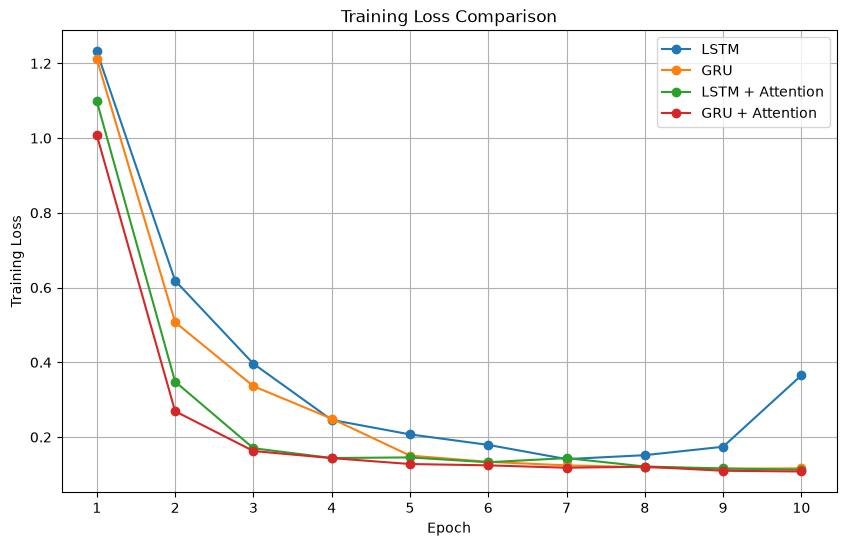

In [56]:
plt.figure(figsize=(10, 6))

epochs = range(1, num_epochs + 1)

plt.plot(epochs, lstm_losses, marker="o", label="LSTM")
plt.plot(epochs, gru_losses, marker="o", label="GRU")
plt.plot(
    epochs,
    lstm_attention_losses,
    marker="o",
    label="LSTM + Attention"
)
plt.plot(
    epochs,
    gru_attention_losses,
    marker="o",
    label="GRU + Attention"
)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.xticks(range(1, num_epochs + 1))
plt.legend()
plt.grid(True)

plt.show()

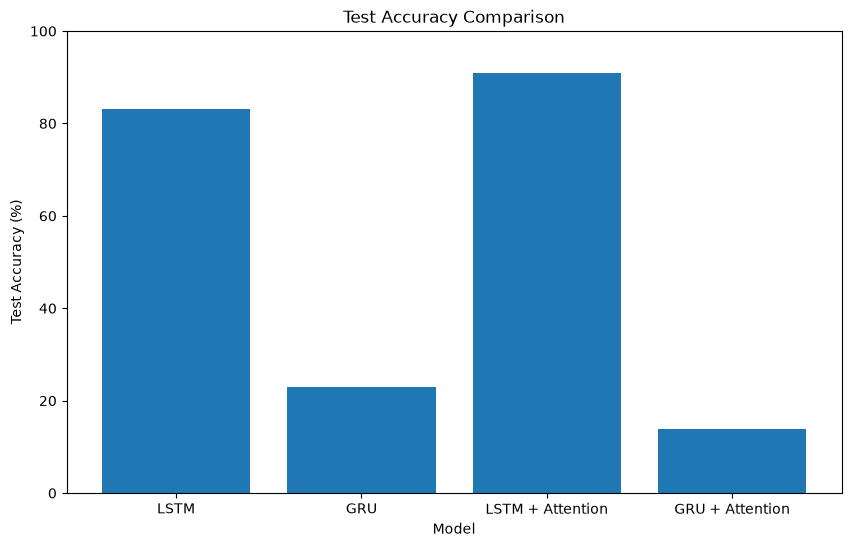

In [57]:
model_names = [
    "LSTM",
    "GRU",
    "LSTM + Attention",
    "GRU + Attention"
]

accuracies = [
    lstm_accuracy,
    gru_accuracy,
    lstm_attention_accuracy,
    gru_attention_accuracy
]

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies)

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

plt.show()

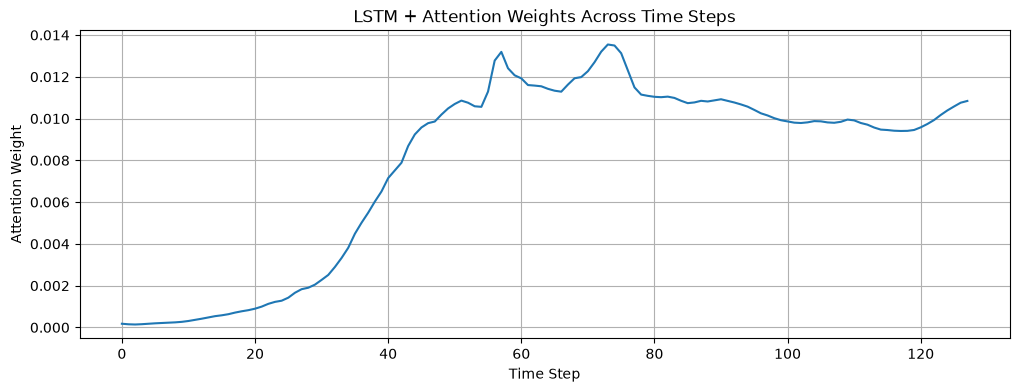

In [58]:
# Get one test sample
sample = X_test[0]

# Convert to tensor and add batch dimension
sample_tensor = torch.tensor(
    sample,
    dtype=torch.float32
).unsqueeze(0).to(device)

# Get attention weights
lstm_attention_model.eval()

with torch.no_grad():
    output, lstm_weights = lstm_attention_model(sample_tensor)

# Convert weights to NumPy
lstm_weights = lstm_weights.squeeze().cpu().numpy()

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(len(lstm_weights)), lstm_weights)

plt.title("LSTM + Attention Weights Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.grid(True)

plt.show()

### Attention Weights Visualization

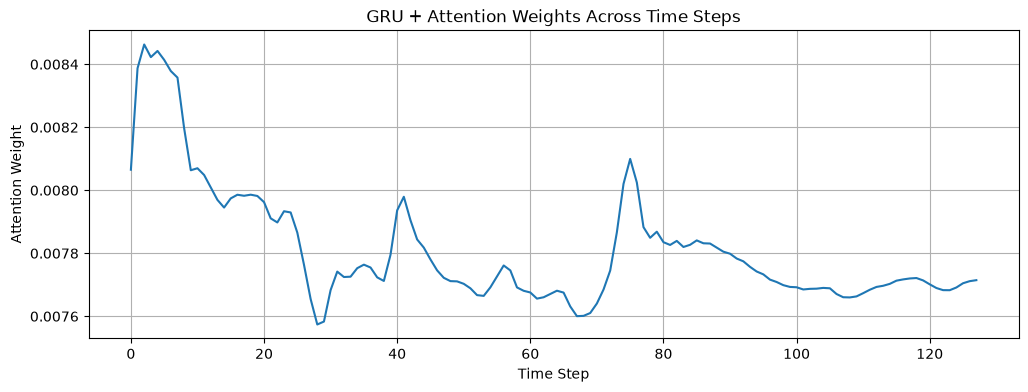

In [59]:
# Get one test sample
sample = X_test[0]

# Convert to tensor and add batch dimension
sample_tensor = torch.tensor(
    sample,
    dtype=torch.float32
).unsqueeze(0).to(device)

# Get attention weights
gru_attention_model.eval()

with torch.no_grad():
    output, gru_weights = gru_attention_model(sample_tensor)

# Convert weights to NumPy
gru_weights = gru_weights.squeeze().cpu().numpy()

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(len(gru_weights)), gru_weights)

plt.title("GRU + Attention Weights Across Time Steps")
plt.xlabel("Time Step")
plt.ylabel("Attention Weight")
plt.grid(True)

plt.show()

## 11. Assignment Questions and Answers

1. Why is your selected dataset suitable for sequence modeling?

I used the Human Activity Recognition dataset. It is suitable for sequence modeling because each sample contains sensor data collected over 128 time steps. The order of these time steps is important, so LSTM and GRU can learn patterns over time to recognize different human activities.

2. Which model has the largest number of parameters? Why?

The LSTM + Attention model has the largest number of parameters, with 19,655. LSTM already has more parameters than GRU, and adding the Attention layer increases the number a little more.

3. Which model has the smallest number of parameters? Why?

The regular GRU has the smallest number of parameters, with 14,790. GRU is simpler than LSTM because it uses fewer gates, and this model also does not have an Attention layer.

4. Which model achieved the highest accuracy?

LSTM + Attention achieved the highest accuracy, which was 90.87%.

5. Which model was the fastest to train?

The regular LSTM was the fastest to train. It took about 31.53 seconds.

6. Which model had the fastest inference time?

The regular LSTM also had the fastest inference time at 0.4313 seconds.

7. Did adding Attention improve LSTM performance?

Yes. The regular LSTM got 88.53%, while LSTM + Attention got 90.87%. So, adding Attention improved the accuracy by 2.34%.

8. Did adding Attention improve GRU performance?

Yes, but the improvement was smaller. GRU got 89.41%, while GRU + Attention got 90.33%. This means the accuracy improved by 0.92%.

9. What is the main trade-off between LSTM and GRU?

GRU has fewer parameters and a simpler structure, while LSTM is more complex and has more parameters. So, GRU is generally lighter, but in this experiment the actual training and inference times were also affected by the implementation and hardware.

10. Based on your results, which model would you choose and why?

Based on my results, I would choose LSTM + Attention. It gave the highest accuracy at 90.87%, and its training time was almost the same as the regular LSTM. The inference time was a little higher, but I think the accuracy improvement makes it the best choice overall.